In [ ]:
NOTES :
#Import libraries
#Upload / connect dataset
#Dataset exploration (EDA)
#Data preprocessing
#CNN model
#MobileNetV2 model
#Model training
#Evaluation (accuracy, confusion matrix)
#Fatigue decision logic
#Fatigue progression curve

In [ ]:
# Import required libraries:

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
#Library vars	Purpose
#tensorflow -->Deep learning
#keras	CNN --> models
#matplotlib-->	graphs
#sklearn --> evaluation metrics

In [ ]:
zip_path = "archive (2).zip"
extract_path = "dataset_raw"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [ ]:
print(os.listdir("dataset_raw")) # checking purpose data has been saved or not

['train']


In [ ]:
#checking
print(os.listdir())

['.config', 'archive (2).zip', 'dataset_raw', 'sample_data']


In [ ]:
print(os.listdir("dataset_raw/train")) # checking

['Closed', 'no_yawn', 'Open', 'yawn']


In [ ]:
# check dataset
dataset_path = "dataset_raw/train"

classes = os.listdir(dataset_path)

for c in classes: # count image per class

    path = os.path.join(dataset_path, c)

    count = len(os.listdir(path))

    print(c, ":", count, "images")

Closed : 726 images
no_yawn : 725 images
Open : 726 images
yawn : 723 images


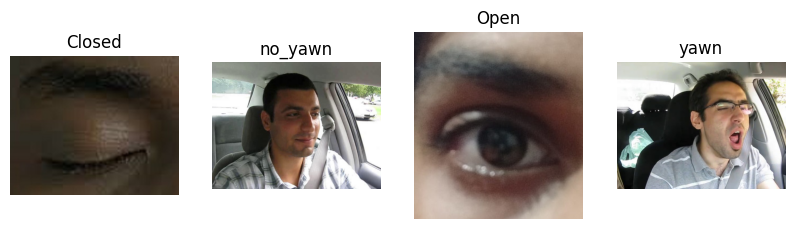

In [ ]:
#EDA :
import random
import cv2
plt.figure(figsize=(10,6))

for i,c in enumerate(classes):

    img_name = random.choice(os.listdir(os.path.join(dataset_path,c)))
    img_path = os.path.join(dataset_path,c,img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,len(classes),i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.show()

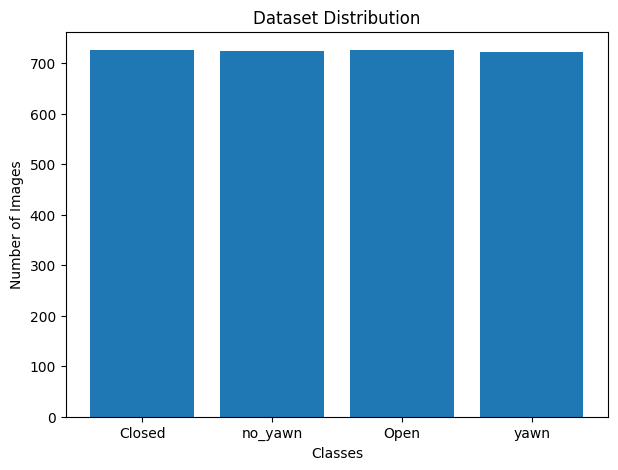

In [ ]:
dataset_path = "dataset_raw/train"
classes = os.listdir(dataset_path)

counts = []

for c in classes:
    counts.append(len(os.listdir(os.path.join(dataset_path,c))))

plt.figure(figsize=(7,5))
plt.bar(classes, counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.show()

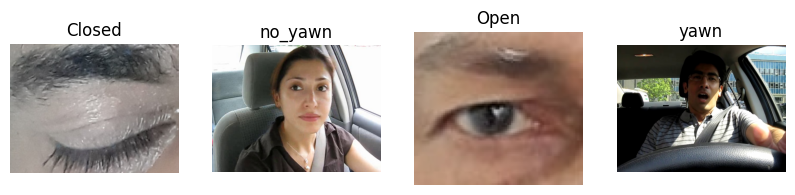

In [ ]:
plt.figure(figsize=(10,6))

for i,c in enumerate(classes):

    img_name = random.choice(os.listdir(os.path.join(dataset_path,c)))
    img_path = os.path.join(dataset_path,c,img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.show()

In [ ]:
from PIL import Image

sizes = []

for c in classes:
    folder = os.path.join(dataset_path,c)

    for img_name in os.listdir(folder)[:50]:
        img = Image.open(os.path.join(folder,img_name))
        sizes.append(img.size)

print("Unique image sizes:", set(sizes))

Unique image sizes: {(311, 300), (126, 126), (267, 230), (449, 542), (461, 461), (300, 300), (313, 300), (166, 165), (111, 110), (328, 300), (130, 117), (299, 285), (432, 320), (341, 300), (330, 300), (123, 123), (616, 486), (300, 311), (517, 437), (107, 90), (734, 734), (314, 300), (87, 84), (799, 799), (358, 300), (97, 97), (111, 96), (371, 300), (426, 300), (125, 125), (131, 104), (245, 245), (456, 300), (334, 256), (333, 300), (573, 574), (230, 192), (112, 111), (311, 265), (943, 823), (96, 96), (433, 300), (181, 182), (279, 242), (280, 280), (266, 308), (195, 147), (82, 69), (329, 300), (305, 300), (384, 300), (439, 300), (86, 69), (410, 300), (237, 238), (389, 253), (135, 135), (186, 183), (130, 130), (306, 300), (154, 105), (104, 58), (348, 354), (93, 85), (323, 300), (133, 112), (226, 169), (336, 300), (143, 143), (354, 354), (242, 241), (230, 230), (102, 99), (576, 577), (77, 54), (601, 576), (364, 300), (69, 68), (87, 83), (1365, 1365), (626, 626), (313, 312), (532, 542), (78

In [ ]:
import shutil

source_dir = "dataset_raw/train"

target_dir = "driver_dataset"

split_ratio = (0.7,0.15,0.15)

classes = ['yawn', 'Open', 'no_yawn', 'Closed']

for c in classes:

    images = os.listdir(os.path.join(source_dir,c))
    random.shuffle(images)

    train_split = int(0.7*len(images))
    val_split = int(0.85*len(images))

    train = images[:train_split]
    val = images[train_split:val_split]
    test = images[val_split:]

    for img in train:

        src = os.path.join(source_dir,c,img)
        dst = os.path.join(target_dir,"train",c,img)

        os.makedirs(os.path.dirname(dst),exist_ok=True)
        shutil.copy(src,dst)

    for img in val:

        src = os.path.join(source_dir,c,img)
        dst = os.path.join(target_dir,"val",c,img)

        os.makedirs(os.path.dirname(dst),exist_ok=True)
        shutil.copy(src,dst)

    for img in test:

        src = os.path.join(source_dir,c,img)
        dst = os.path.join(target_dir,"test",c,img)

        os.makedirs(os.path.dirname(dst),exist_ok=True)
        shutil.copy(src,dst)

print("Dataset split completed")

Dataset split completed


In [ ]:
for folder in ["train","val","test"]:

    print("\n", folder.upper())

    path = os.path.join("driver_dataset", folder)

    for c in os.listdir(path):

        count = len(os.listdir(os.path.join(path,c)))

        print(c, ":", count)


 TRAIN
Closed : 508
no_yawn : 507
Open : 508
yawn : 506

 VAL
Closed : 109
no_yawn : 109
Open : 109
yawn : 108

 TEST
Closed : 109
no_yawn : 109
Open : 109
yawn : 109


In [ ]:
# data preprocessing and augmentation:
IMG_SIZE=(224,224)
BATCH_SIZE=32

train_datagen = ImageDataGenerator(

rescale=1./255,
rotation_range=20,
zoom_range=0.2,
brightness_range=[0.8,1.2],
horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

#load dataset
train_generator = train_datagen.flow_from_directory(

"driver_dataset/train",
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(

"driver_dataset/val",
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(

"driver_dataset/test",
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode="categorical",
shuffle=False
)

Found 2029 images belonging to 4 classes.
Found 435 images belonging to 4 classes.
Found 436 images belonging to 4 classes.


In [ ]:
print(train_generator.class_indices)
#classes = ["Closed","No_Yawn","Open","Yawn"] output should be:

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [ ]:
# Custom CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential()

cnn_model.add(Input(shape=(224,224,3)))

cnn_model.add(Conv2D(32,(3,3),activation="relu"))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(64,(3,3),activation="relu"))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(128,(3,3),activation="relu"))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128,activation="relu"))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(4,activation="softmax"))

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.save("drowsiness_model.keras")

#Layer	vs Purpose:
Conv2D -->Detect edges & features,
MaxPooling -->Reduce image size,
Conv2D -->Detect deeper patterns,
MaxPooling -->Reduce dimensions,
Conv2D -->Learn complex facial patterns,
MaxPooling -->	Feature compression,
Flatten -->	Convert image features to vector,
Dense	-->Learn classification,
Softmax-->Predict class.

In [ ]:
# Transfer Learning
base_model = MobileNetV2(

input_shape=(224,224,3),
include_top=False,
weights="imagenet"
)

for layer in base_model.layers[:-30]:
    layer.trainable=False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128,activation="relu")(x)
x = Dropout(0.5)(x)

predictions = Dense(4,activation="softmax")(x)

mobilenet_model = Model(inputs=base_model.input,outputs=predictions)

#lightweight
#fast inference
#used in real embedded systems.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#compile the model.

mobilenet_model.compile(

optimizer=Adam(learning_rate=0.0001),
loss="categorical_crossentropy",
metrics=["accuracy"]
)
mobilenet_model.summary()

# train  model
history = mobilenet_model.fit(

train_generator,
validation_data=val_generator,
epochs=15
)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 1,690,884 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 967ms/step - accuracy: 0.7467 - loss: 0.5364 - val_accuracy: 0.7862 - val_loss: 0.3647
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 486ms/step - accuracy: 0.8980 - loss: 0.2449 - val_accuracy: 0.7517 - val_loss: 0.5440
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 469ms/step - accuracy: 0.9399 - loss: 0.1546 - val_accuracy: 0.7908 - val_loss: 0.5535
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 481ms/step - accuracy: 0.9645 - loss: 0.0998 - val_accuracy: 0.8299 - val_loss: 0.4419
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 472ms/step - accuracy: 0.9763 - loss: 0.0702 - val_accuracy: 0.8115 - val_loss: 0.5055
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 499ms/step - accuracy: 0.9714 - loss: 0.0752 - val_accuracy: 0.8483 - val_loss: 0.3697
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 467ms/step - accuracy: 0.9773 - loss: 0.0722 - val_accuracy: 0.8966 - val_loss: 0.2602
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 473ms/step - accuracy: 0.9828 - loss: 0.0509 - val_accu

In [ ]:
# evaluate model:

loss,accuracy = mobilenet_model.evaluate(test_generator)
print("Test Accuracy:",accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 939ms/step - accuracy: 0.9839 - loss: 0.0383
Test Accuracy: 0.9839449524879456


In [ ]:
mobilenet_model.save("driver_drowsiness_model.keras") # save model:

In [ ]:
print(os.listdir("dataset_raw/train"))

['Closed', 'no_yawn', 'Open', 'yawn']


Testing Image Path: dataset_raw/train/Open/_327.jpg


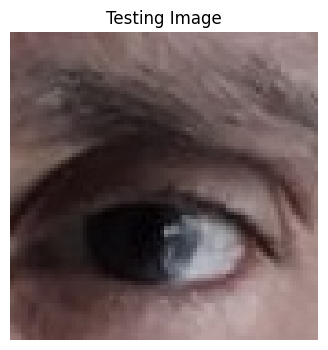

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
Predicted Class: Open
Confidence: 26.242348 %
Driver Status: Driver Alert


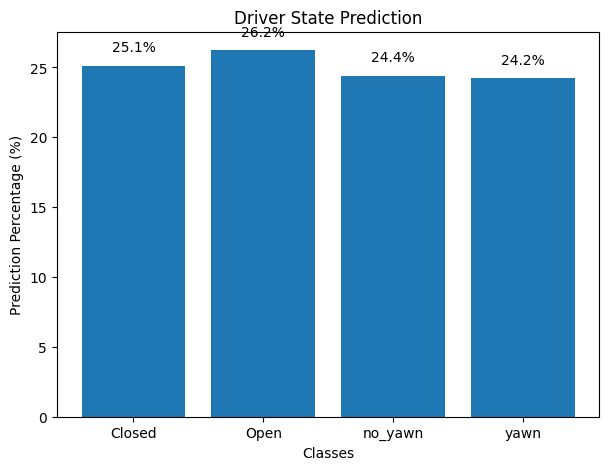

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image

# class labels
class_labels = ['Closed','Open','no_yawn','yawn']

# dataset path (use test folder)
dataset_path = "dataset_raw/train"

# choose random class
random_class = random.choice(class_labels)

# choose random image
folder = os.path.join(dataset_path, random_class)
img_name = random.choice(os.listdir(folder))

img_path = os.path.join(folder, img_name)

print("Testing Image Path:", img_path)

# load image
image = Image.open(img_path)

# show testing image
plt.figure(figsize=(4,4))
plt.imshow(image)
plt.title("Testing Image")
plt.axis("off")
plt.show()

# resize image
img = image.resize((224,224))

# convert to numpy
img = np.array(img)

# preprocess for MobileNetV2
img = preprocess_input(img)

# add batch dimension
img = np.expand_dims(img, axis=0)

# prediction
prediction = cnn_model.predict(img)

# probability %
probabilities = prediction[0] * 100

# predicted class
predicted_index = np.argmax(probabilities)
predicted_label = class_labels[predicted_index]

# Driver status logic
if predicted_label in ['Closed','yawn']:
    status = "Driver Drowsy"
else:
    status = "Driver Alert"

print("Predicted Class:", predicted_label)
print("Confidence:", probabilities[predicted_index], "%")
print("Driver Status:", status)

# Bar Graph
plt.figure(figsize=(7,5))
plt.bar(class_labels, probabilities)

for i,v in enumerate(probabilities):
    plt.text(i, v+1, f"{v:.1f}%", ha='center')

plt.xlabel("Classes")
plt.ylabel("Prediction Percentage (%)")
plt.title("Driver State Prediction")
plt.show()

In [ ]:
# confusion matrix:

pred = mobilenet_model.predict(test_generator)

pred_classes = np.argmax(pred,axis=1)

cm = confusion_matrix(test_generator.classes,pred_classes)

print(cm)

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 402ms/step
[[109   0   0   0]
 [  0 109   0   0]
 [  0   0 105   4]
 [  0   0   3 106]]


In [ ]:
print(classification_report(test_generator.classes,pred_classes)) # classification report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       109
           2       0.97      0.96      0.97       109
           3       0.96      0.97      0.97       109

    accuracy                           0.98       436
   macro avg       0.98      0.98      0.98       436
weighted avg       0.98      0.98      0.98       436



#flow
Load Data
   -->
Train Generator
  -->
Validation Generator
   -->
Test Generator
   -->
Build CNN
   -->
Train Model
   -->
Evaluate Test Accuracy

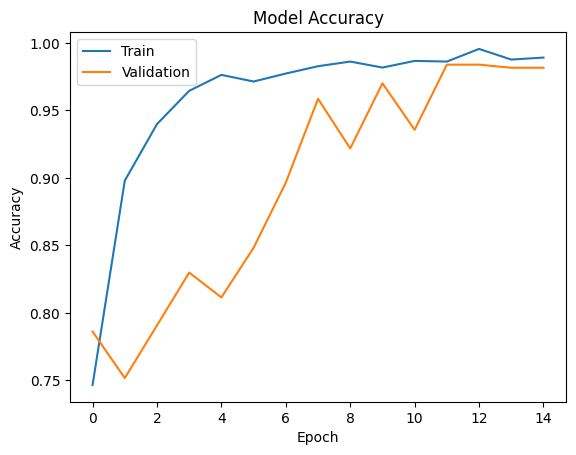

In [ ]:
# accuracy & loss freq -graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])
plt.show()



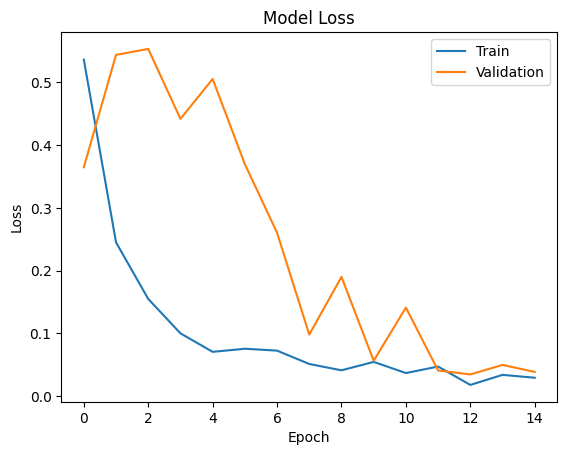

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

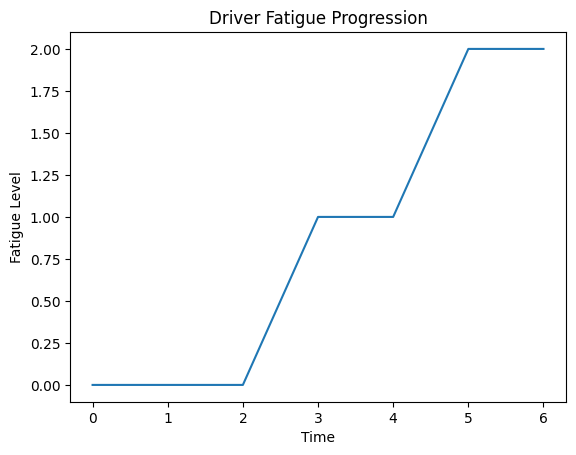

In [ ]:
# Convert 4 classes → 3 fatigue levels:
def fatigue_stage(pred):

    if pred in ["open","no_yawn"]:
        return 0

    elif pred=="yawn":
        return 1

    elif pred=="closed":
        return 2

# Fatigue Progression Curve:

predictions = [
"open","open","open",
"yawn","yawn",
"closed","closed"
]

levels=[]

for p in predictions:

    if p in ["open","no_yawn"]:
        levels.append(0)

    elif p=="yawn":
        levels.append(1)

    else:
        levels.append(2)

plt.plot(levels)

plt.xlabel("Time")
plt.ylabel("Fatigue Level")

plt.title("Driver Fatigue Progression")

plt.show()

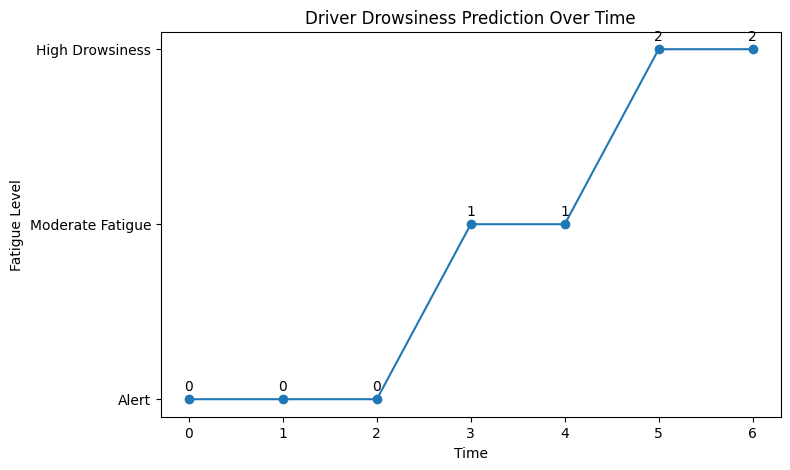

In [ ]:
time = [0,1,2,3,4,5,6]
fatigue = [0,0,0,1,1,2,2]

plt.figure(figsize=(8,5))

plt.plot(time,fatigue,marker='o')

plt.xlabel("Time")
plt.ylabel("Fatigue Level")

plt.title("Driver Drowsiness Prediction Over Time")

plt.yticks([0,1,2],["Alert","Moderate Fatigue","High Drowsiness"])

# annotate prediction points
for i in range(len(time)):
    plt.text(time[i], fatigue[i]+0.05, str(fatigue[i]), ha='center')

plt.show()

In [ ]:
#Performance Analysis:
# just added the names #:

predictions = mobilenet_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00       109
        Open       1.00      1.00      1.00       109
     no_yawn       0.97      0.96      0.97       109
        yawn       0.96      0.97      0.97       109

    accuracy                           0.98       436
   macro avg       0.98      0.98      0.98       436
weighted avg       0.98      0.98      0.98       436



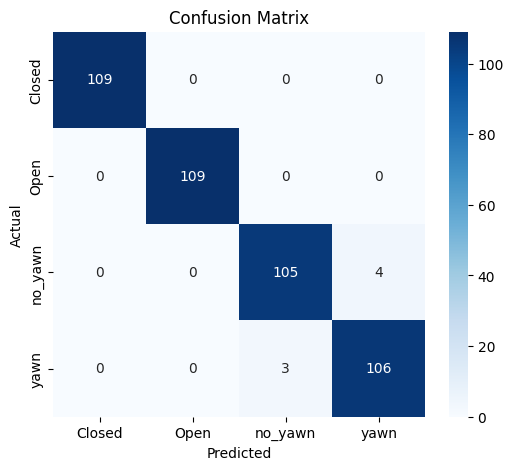

In [ ]:
# Confusion Matrix (Error Analysis):--> which classes the model confuses.
import seaborn as sns
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

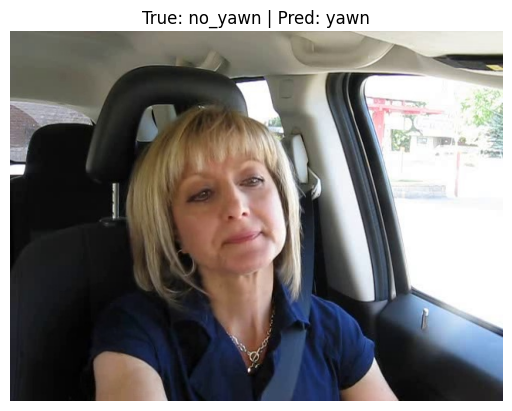

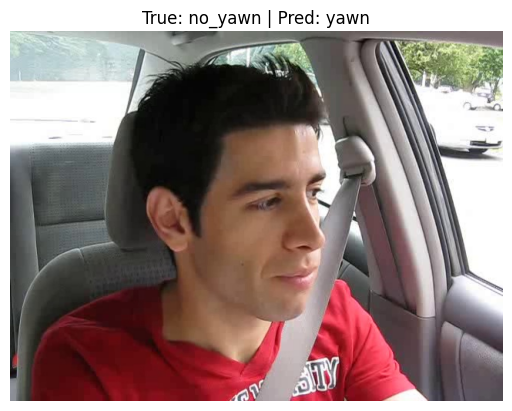

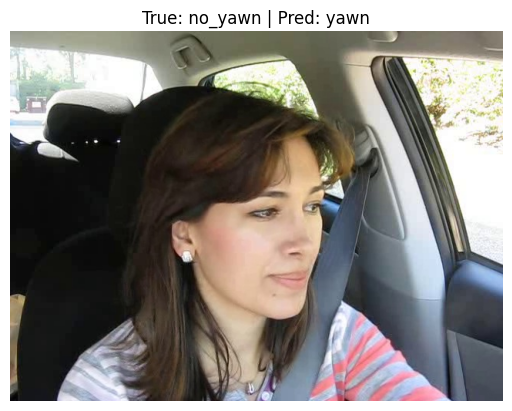

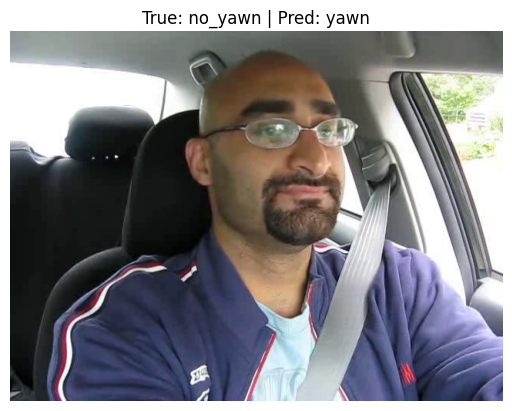

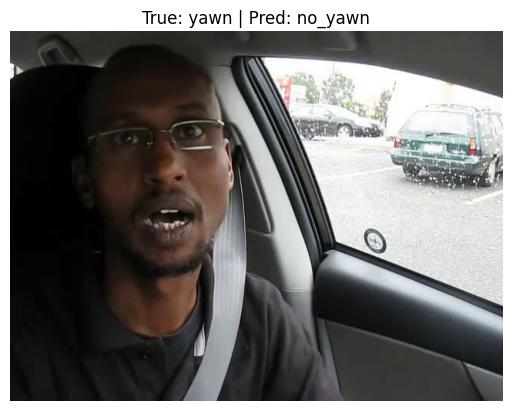

In [ ]:
# Error Case Visualization --> wrong predictions:

wrong = np.where(predicted_classes != true_classes)[0]

for i in wrong[:5]:

    img_path = test_generator.filepaths[i]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"True: {class_labels[true_classes[i]]} | Pred: {class_labels[predicted_classes[i]]}")
    plt.axis("off")
    plt.show()

In [ ]:
import pandas as pd
import os

# same dataset path used in your notebook
dataset_path = "dataset_raw/train"

data = []

classes = os.listdir(dataset_path)

for label in classes:

    folder_path = os.path.join(dataset_path, label)

    for img in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img)

        data.append([img_path, label])

# Create dataframe
df = pd.DataFrame(data, columns=["image_path", "label"])

# Save CSV
df.to_csv("driver_drowsiness_dataset.csv", index=False)

print("CSV file created successfully!")
print("Total images:", len(df))
df.tail()

CSV file created successfully!
Total images: 2900


,image_path,label
2895,dataset_raw/train/yawn/205.jpg,yawn
2896,dataset_raw/train/yawn/102.jpg,yawn
2897,dataset_raw/train/yawn/71.jpg,yawn
2898,dataset_raw/train/yawn/506.jpg,yawn
2899,dataset_raw/train/yawn/422.jpg,yawn


In [ ]:
pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 141.8 MB/s eta 0:00:00


In [ ]:
pip install pyngrok

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(
    page_title="Driver Drowsiness Detection Dashboard",
    page_icon="🚗",
    layout="wide"
)

# -----------------------------
# HEADER
# -----------------------------
st.title("🚗 Driver Drowsiness Detection Dashboard")
st.markdown("### AI-Based Driver Fatigue Monitoring System")

st.markdown("---")

# -----------------------------
# SIDEBAR
# -----------------------------
st.sidebar.header("Dashboard Controls")

refresh = st.sidebar.button("🔄 Refresh Metrics")

st.sidebar.markdown("### About Project")
st.sidebar.info("""
This dashboard demonstrates an **AI-based driver drowsiness detection system**.

It monitors driver fatigue levels and alerts when drowsiness is detected.

**Technologies Used**
- Python
- Deep Learning
- Computer Vision
- Streamlit
""")

# -----------------------------
# KPI METRICS
# -----------------------------

col1, col2, col3, col4 = st.columns(4)

alert_percentage = np.random.randint(70,95)
drowsy_percentage = 100 - alert_percentage
alerts_triggered = np.random.randint(3,15)
avg_blink_rate = np.random.randint(12,25)

col1.metric("Driver Alertness", f"{alert_percentage}%")
col2.metric("Drowsiness Probability", f"{drowsy_percentage}%")
col3.metric("Alerts Triggered", alerts_triggered)
col4.metric("Avg Blink Rate", f"{avg_blink_rate}/min")

st.markdown("---")

# -----------------------------
# DRIVER STATUS
# -----------------------------

st.subheader("Driver Status Monitor")

status_col1, status_col2 = st.columns(2)

with status_col1:

    fatigue_level = np.random.randint(0,100)

    st.progress(fatigue_level)

    if fatigue_level < 40:
        st.success("Driver Status: ALERT")
    elif fatigue_level < 70:
        st.warning("Driver Status: MODERATE FATIGUE")
    else:
        st.error("Driver Status: HIGH DROWSINESS")

with status_col2:

    st.write("### Fatigue Level Chart")

    fig = plt.figure()
    plt.bar(["Fatigue Level"], [fatigue_level])
    plt.ylim(0,100)
    plt.ylabel("Fatigue Level")
    st.pyplot(fig)

st.markdown("---")

# -----------------------------
# ANALYTICS
# -----------------------------

st.subheader("Driver Monitoring Analytics")

colA, colB = st.columns(2)

with colA:

    st.write("### Alert vs Drowsy Distribution")

    fig1 = plt.figure()

    labels = ["Alert","Drowsy"]
    values = [alert_percentage, drowsy_percentage]

    plt.pie(values, labels=labels, autopct='%1.1f%%')
    st.pyplot(fig1)

with colB:

    st.write("### Eye Blink Rate Trend")

    blink_data = np.random.randint(10,25,10)

    fig2 = plt.figure()
    plt.plot(blink_data, marker="o")
    plt.xlabel("Time")
    plt.ylabel("Blink Rate")
    st.pyplot(fig2)

st.markdown("---")

# -----------------------------
# IMAGE ANALYSIS
# -----------------------------

st.subheader("Driver Image Analysis")

uploaded_file = st.file_uploader("Upload Driver Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:

    image = Image.open(uploaded_file)

    colX, colY = st.columns(2)

    with colX:
        st.image(image, caption="Uploaded Image", use_column_width=True)

    with colY:

        st.write("### Prediction Result")

        with st.spinner("Analyzing Driver State..."):
            time.sleep(2)

        prediction = np.random.choice(["Alert","Drowsy"])

        if prediction == "Alert":
            st.success("Prediction: Driver is ALERT")
        else:
            st.error("Prediction: Driver is DROWSY")

st.markdown("---")

# -----------------------------
# ALERT LOG TABLE
# -----------------------------

st.subheader("Recent Alert Logs")

data = {
    "Time":["10:01 AM","10:15 AM","10:30 AM","11:05 AM","11:20 AM"],
    "Driver Status":["Alert","Drowsy","Alert","Drowsy","Alert"],
    "Action Taken":["None","Alarm Triggered","None","Voice Alert","None"]
}

df = pd.DataFrame(data)

st.dataframe(df, use_container_width=True)

st.markdown("---")

# -----------------------------
# SYSTEM PERFORMANCE
# -----------------------------

st.subheader("System Performance")

p1, p2, p3 = st.columns(3)

p1.metric("Model Accuracy","94%")
p2.metric("Detection Speed","0.25 sec")
p3.metric("Camera FPS","30 FPS")

st.markdown("---")

# -----------------------------
# PROJECT METHODOLOGY
# -----------------------------

st.subheader("Project Methodology")

st.markdown("""
1. A well-prepared and standardized facial image dataset was created with resizing, normalization and augmentation.

2. A structured dataset containing four classes: **Eyes Open, Eyes Closed, Yawn and No Yawn**.

3. Deep learning models capable of accurately detecting driver eye closure and yawning.

4. A rule-based fusion mechanism to classify driver alertness levels as **Alert, Moderate Drowsiness or High Drowsiness**.

5. Comprehensive evaluation including preprocessing, training, performance metrics and driver safety recommendations.
""")

st.markdown("---")

# -----------------------------
# FOOTER
# -----------------------------

st.markdown("""
### 🚗 Driver Drowsiness Detection System

Developed using **Artificial Intelligence, Deep Learning and Computer Vision**

Dashboard built with **Streamlit + Python**
""")

Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3AiEwhTgj1O4v4XNJFv3xufPFvq_7gjAFb3C1gPyHrWDNyuqw")

# https://dashboard.ngrok.com/get-started/your-authtoken --> link

In [ ]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [ ]:
!streamlit run /content/app.py &>/content/logs.txt & npx localtunnel --port 8501 & curl ipv4.icanhazip.com

34.80.50.121
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://unsurcharged-douglas-bribeable.ngrok-free.dev" -> "http://localhost:8501">